# Ford Car Price Prediction Using Machine Learning

## 1. Project Overview

This project focuses on predicting the price of Ford cars using machine learning.

The dataset, `ford.csv`, was obtained from Kaggle and contains different specifications and characteristics of Ford vehicles. The objective is to predict the numerical price of a car based on its available features.

Since the target variable is a continuous numerical value, this is a regression problem.

Two different regression approaches were explored during the project: **Linear Regression and Random Forest Regressor.**

---

## 2. Project Objective

The main objective is to develop a machine-learning model capable of estimating the price of a Ford vehicle based on its specifications.

The project follows a complete machine-learning workflow:

**Data** → **EDA** → **Cleaning** → **Preprocessing** → **Model Comparison** → **Model Optimization** → **Evaluation** → **Final Model**

---

## 3. Dataset

- Dataset: `ford.csv`
- Source: Kaggle
- Problem Type: Regression
- Target: Car Price

The dataset contains information about Ford vehicles, including different specifications and characteristics that can be used to estimate their prices.

---

## 4. Libraries and Environment

All required Python libraries were imported together at the beginning of the project.

This kept the workflow organized and avoided repeatedly importing the same libraries throughout different sections of the analysis.

The imported libraries were used for:

- Data manipulation
- Numerical calculations
- Data visualization
- Data preprocessing
- Model training
- Hyperparameter optimization
- Model evaluation

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [78]:
df = pd.read_csv(r"ford.csv")
df["year"].max()

np.int64(2060)

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed before model training to understand the dataset and identify potential data-quality issues.

The analysis included:

- Inspecting the first rows of the dataset
- Checking the dataset dimensions
- Examining data types
- Checking missing values
- Checking duplicate records
- Generating descriptive statistics
- Examining numerical feature distributions
- Analyzing categorical variables
- Investigating relationships between vehicle specifications and price

The purpose of EDA was to understand the characteristics of the data and determine the appropriate preprocessing steps before machine-learning training.

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.6 MB


In [80]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

In [81]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [82]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: >

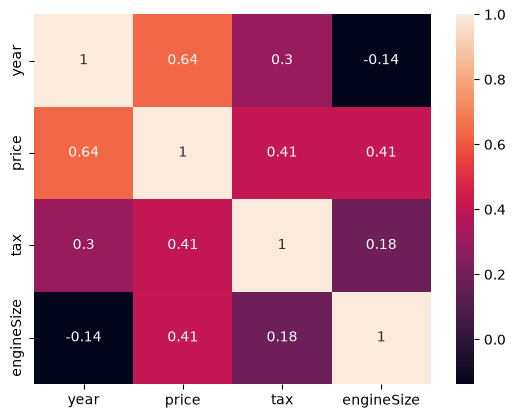

In [83]:
A1 = df.drop(columns=["mileage","mpg"])
sns.heatmap(A1.select_dtypes("number").corr(), annot=True)

<Axes: xlabel='year', ylabel='engineSize'>

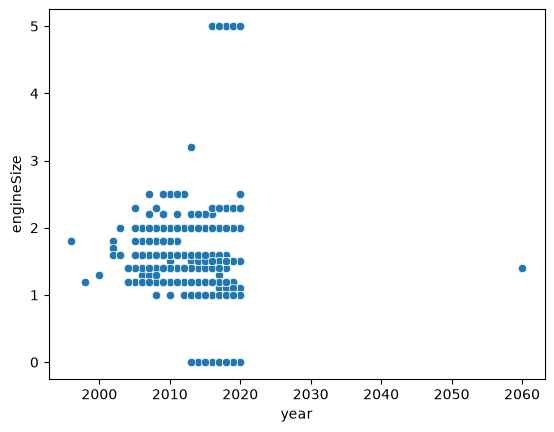

In [84]:
sns.scatterplot(x=df["year"],y=df["engineSize"])

In [85]:
for col in df.select_dtypes("str"):
    print(f"{col}:{df[col].unique()}")

model:<ArrowStringArray>
[               ' Fiesta',                 ' Focus',                  ' Puma',
                  ' Kuga',              ' EcoSport',                 ' C-MAX',
                ' Mondeo',                   ' Ka+',        ' Tourneo Custom',
                 ' S-MAX',                 ' B-MAX',                  ' Edge',
       ' Tourneo Connect',           ' Grand C-MAX',                    ' KA',
                ' Galaxy',               ' Mustang', ' Grand Tourneo Connect',
                ' Fusion',                ' Ranger',              ' Streetka',
                ' Escort',       ' Transit Tourneo',                  'Focus']
Length: 24, dtype: str
transmission:<ArrowStringArray>
['Automatic', 'Manual', 'Semi-Auto']
Length: 3, dtype: str
fuelType:<ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid', 'Electric', 'Other']
Length: 5, dtype: str


## 6. Data Cleaning

After completing the initial EDA, the dataset was prepared for machine learning.

Relevant data-quality issues were addressed, and unnecessary or unsuitable information was removed where required.

The objective was to produce a clean dataset containing useful information for predicting vehicle prices.

In [86]:
def replace_outliers_with_median(df, columns):
    for col in columns:
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median_val = df[col].median()
        
        df.loc[df[col] < lower_bound, col] = median_val
        df.loc[df[col] > upper_bound, col] = median_val
    return df

columns_to_clean = ['year', 'price', 'tax', 'engineSize',"mpg"]  # replace with your actual column names
replace_outliers_with_median(df, columns_to_clean)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [87]:


def replace_outliers_with_median(df, columns):
    for col in columns:
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median_val = df[col].mean()
        
        df.loc[df[col] < lower_bound, col] = median_val.round(0)
        df.loc[df[col] > upper_bound, col] = median_val.round(0)
    return df

columns_to_clean = ["mileage"]  # replace with your actual column names
replace_outliers_with_median(df, columns_to_clean)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


<Axes: ylabel='mpg'>

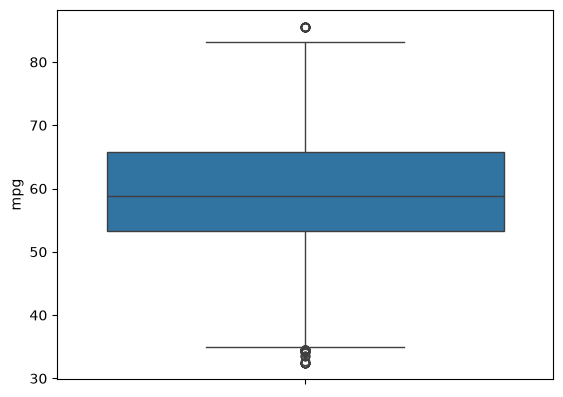

In [88]:
sns.boxplot(df["mpg"])
# df

<Axes: >

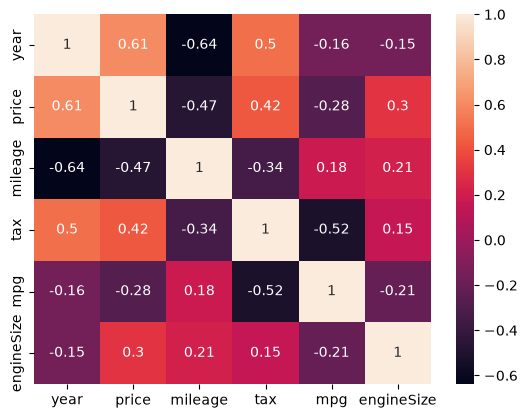

In [89]:
sns.heatmap(df.select_dtypes("number").corr(), annot=True)

<Axes: xlabel='price', ylabel='Count'>

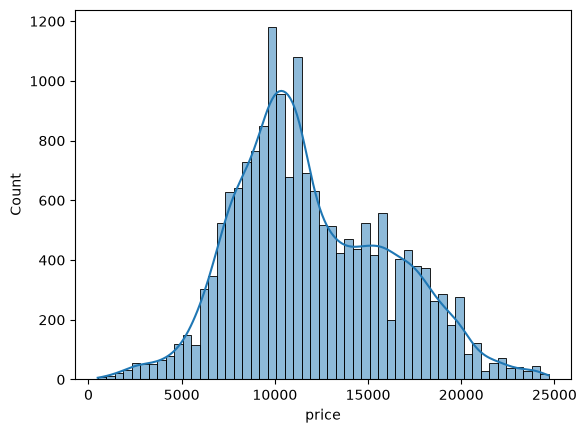

In [90]:
sns.histplot(df["price"], kde=True)

In [91]:
import numpy as np

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)   # price can't be negative
upper = Q3 + 1.5 * IQR

# Cap instead of delete
df['price_capped'] = df['price'].clip(lower=lower, upper=upper)

<Axes: xlabel='mileage', ylabel='engineSize'>

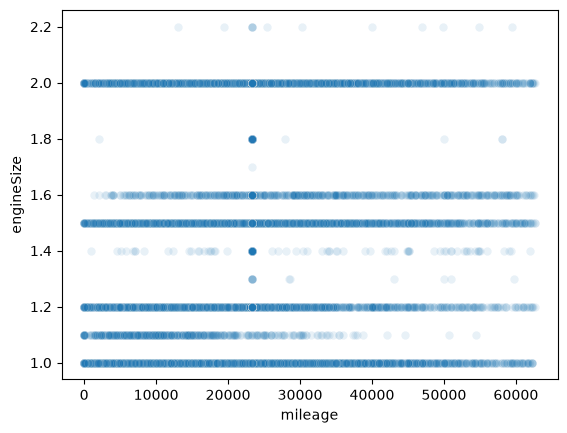

In [92]:
sns.scatterplot(x=df["mileage"],y=df["engineSize"],alpha = 0.1)

In [93]:
print(df['model'].value_counts())
top_10_brands = df['model'].value_counts().nlargest(10).index
print(top_10_brands)
df['model'] = df['model'].where(df['model'].isin(top_10_brands), 'Other')

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64
Index([' Fiesta', ' Focus', ' Kuga', ' EcoSport', ' C-MAX', ' Ka+', ' Mondeo',
       ' B-MAX', ' S-MAX', ' Grand C-MAX'],
      dtype='str', name='model')


In [94]:
print(df['model'].value_counts())
print(df['fuelType'].value_counts())
print(df['transmission'].value_counts())

model
 Fiesta         6557
 Focus          4588
 Kuga           2225
 EcoSport       1143
Other            955
 C-MAX           543
 Ka+             531
 Mondeo          526
 B-MAX           355
 S-MAX           296
 Grand C-MAX     247
Name: count, dtype: int64
fuelType
Petrol      12179
Diesel       5762
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64
transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64


In [95]:
df[["model","transmission","fuelType"]]

,model,transmission,fuelType
0,Fiesta,Automatic,Petrol
1,Focus,Manual,Petrol
2,Focus,Manual,Petrol
3,Fiesta,Manual,Petrol
4,Fiesta,Automatic,Petrol
...,...,...,...
17961,B-MAX,Manual,Petrol
17962,B-MAX,Manual,Petrol
17963,Focus,Manual,Diesel
17964,Other,Manual,Petrol


## 7. Feature and Target Selection

The car price was selected as the target variable.

The remaining relevant vehicle specifications were used as predictor variables.
```
cat_cols = ["model", "transmission", "fuelType"]
num_cols = ["engineSize", "mpg", "mileage", "tax"]
X = df[cat_cols + num_cols]
y = df["price"]
```

Here:

X represents the input features.
y represents the car price that the model needs to predict.

---

## 8. Data Preprocessing and Pipeline

The dataset contains both numerical and categorical features, so preprocessing was required before training the machine-learning models.

A Scikit-learn Pipeline was used to organize the preprocessing and modeling workflow.

The pipeline ensures that the same preprocessing steps are consistently applied to the data before it is passed to the model.

The preprocessing workflow included appropriate transformations for numerical and categorical features, such as:

- Handling numerical features
- Encoding categorical features
- Combining the preprocessing steps into a single workflow
- Passing the transformed data directly to the regression model

Using a pipeline also helps reduce the risk of applying different preprocessing steps to the training and testing data.

A simplified structure of the workflow is:

1. **Raw Features**
     ↓
2. **Preprocessing**
     ↓
- Numerical Features
- Categorical Features
3. **Transformed Features**
     ↓
4. **Regression Model**
     ↓
5. **Predicted Price**

The pipeline was also useful during hyperparameter optimization because the preprocessing and model could be treated as a single machine-learning workflow.

In [96]:
# Define which columns get which treatment
cat_cols = ["model", "transmission", "fuelType"]
num_cols = ["engineSize", "mpg", "mileage", "tax"]
target = ["price"]

X = df[cat_cols + num_cols]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build separate mini-pipelines for each category type
Standard_Scaling = StandardScaler()
One_Hot_Encoder = OneHotEncoder(handle_unknown='ignore')

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

# ---- Final pipeline ----
base_pipeline_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])


reg_pipeline = TransformedTargetRegressor(
    regressor=base_pipeline_reg,
    func=np.log1p,        # transform y before fit
    inverse_func=np.expm1 # reverse predictions back to original scale
)

reg_pipeline.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['model','transmission','fuelType',...,'mpg','mileage','tax']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,7
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...egression())])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"


## 10. Model Development

Instead of relying on a single algorithm, multiple regression approaches were tested to determine which could model the relationship between vehicle specifications and price more effectively.

### 10.1 Linear Regression

The first model tested was Linear Regression.

Linear Regression attempts to model the relationship between the input features and the target price using a linear relationship.

The model was trained using the prepared training data and evaluated on the test data.

However, the Linear Regression model did not provide sufficiently strong results for this dataset.

This indicated that the relationship between the vehicle specifications and price was likely more complex than what a simple linear model could adequately capture.

In [97]:
from sklearn.metrics import mean_squared_error
y_pred = reg_pipeline.predict(X_test)
R2_Score_Lin = r2_score(y_test, y_pred)
MSE_Lin = mean_squared_error(y_test, y_pred)
print(f"R2 Score: {R2_Score_Lin}")



R2 Score: 0.5059600260377444


### 10.2 Random Forest Regressor

After evaluating Linear Regression, a Random Forest Regressor was tested.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce predictions.

Unlike a simple linear model, Random Forest can capture more complex and non-linear relationships between vehicle specifications and price.

The Random Forest model produced better results than the initial Linear Regression model, so it was selected for further optimization.

In [98]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor()),
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['model','transmission','fuelType',...,'mpg','mileage','tax']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

## 11. Hyperparameter Optimization

After obtaining better results with Random Forest, the model was further optimized rather than using the initial Random Forest configuration as the final model.

RandomizedSearchCV was used for hyperparameter tuning.

RandomizedSearchCV tests different combinations of selected hyperparameters and evaluates their performance using cross-validation.

This allowed the model to search for a more effective combination of parameters without manually testing every possible combination.

The optimization process considered relevant Random Forest parameters such as:

- Number of trees
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples required at a leaf
- Number of features considered for each split

The best-performing parameter combination identified through the search was then used to create the optimized Random Forest Regressor.

## 12. Cross-Validation

Cross-validation was incorporated into the hyperparameter-search process to provide a more reliable evaluation of different parameter combinations.

Rather than evaluating a configuration using only one train-validation split, the data was divided into multiple folds.

The model was trained and evaluated across these folds, and the results were used to determine which hyperparameter configuration performed most consistently.

This helped reduce the possibility of selecting a model based on a particularly favorable single split.

In [100]:
# Random Forest model
rf_pipeline_modified = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
param_dist = {
    "model__n_estimators": [100,200, 500, 1000],
    "model__max_depth": [None, 10, 15, 20, 25, 30, 40, 50],
    "model__min_samples_split": [2, 3, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
    "model__bootstrap": [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_pipeline_modified,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best CV score
print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
y_pred = rf_pipeline.predict(X_test)
R2_Score_rf = r2_score(y_test, y_pred)
MSE_rf = mean_squared_error(y_test, y_pred)
print(f"R2 Score: {R2_Score_rf}")
print(f"MSE: {MSE_rf**0.5}")


R2 Score: 0.8525339400059688
MSE: 1611.5148027199982


In [ ]:
rf_pipeline_modified = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators= 500, 
        min_samples_split= 10, 
        min_samples_leaf= 5, 
        max_features= 0.7, 
        max_depth= None, 
        bootstrap= True
        )),
    ])

rf_pipeline_modified.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['model','transmission','fuelType',...,'mpg','mileage','tax']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

In [ ]:
y_pred = rf_pipeline_modified.predict(X_test)
R2_Score_rf_modified = r2_score(y_test, y_pred)
MSE_rf_modified = mean_squared_error(y_test, y_pred)
MAE_rf_modified = mean_absolute_error(y_test, y_pred)
print(f"R2 Score: {R2_Score_rf_modified}")

R2 Score: 0.8607216343521782


## 13. Final Model

After comparing Linear Regression with Random Forest and subsequently optimizing the Random Forest model using RandomizedSearchCV, the optimized Random Forest Regressor was used as the final model.

The final model therefore represents the result of:

**Initial Model** → **Model Comparison** → **Random Forest** → **Hyperparameter Tuning** → **Optimized Random Forest**

In [ ]:
print(f"R2 Score for Linear Regression: {R2_Score_Lin}")
print(f"MAE for Linear Regression: {MSE_Lin}")
print(f"R2 Score for Random Forest: {R2_Score_rf}")
print(f"R2 Score for Random Forest Modified: {R2_Score_rf_modified}")
print(f"MAE for Random Forest Modified: {MSE_rf_modified** 0.5}")

R2 Score for Linear Regression: 0.5059600260377444
MAE for Linear Regression: 8700387.81511712
R2 Score for Random Forest: 0.8525339400059688
R2 Score for Random Forest Modified: 0.8607216343521782
MAE for Random Forest Modified: 1566.1382323894802


## 14. Model Evaluation

Because this is a regression problem, regression metrics were used to evaluate the models.

The main metrics include:

#### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted prices.

Lower values indicate smaller average prediction errors.

#### Mean Squared Error (MSE)

Measures the average squared difference between actual and predicted prices.

Large errors have a greater effect because the errors are squared.

#### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE and is expressed in the same unit as the predicted price.

#### R² Score

R² measures how much of the variation in car prices is explained by the model.

These metrics were used to compare the initial Linear Regression model, the Random Forest model, and the optimized Random Forest model.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Regenerate predictions FRESH (in case old y_pred is stale)
y_pred = rf_pipeline.predict(X_test)

# Compute metrics — no flattening needed, shapes already match
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²:         {r2:.4f}")
print(f"MAE:        ${mae:,.2f}")
print(f"MSE:        ${mse:,.2f}")
print(f"RMSE:       ${rmse:,.2f}")
print(f"RMSE / MAE: {rmse / mae:.4f}")

print()
print(f"y_test range: {y_test.min():,.2f} – {y_test.max():,.2f}")
print(f"y_pred range: {y_pred.min():,.2f} – {y_pred.max():,.2f}")

R²:         0.8525
MAE:        $1,107.50
MSE:        $2,596,979.96
RMSE:       $1,611.51
RMSE / MAE: 1.4551

y_test range: 495.00 – 24,500.00
y_pred range: 1,391.14 – 23,910.00


In [ ]:
# Regenerate predictions — don't reuse old variables
y_pred = rf_pipeline_modified.predict(X_test)

# Compute everything fresh
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE:        ${mae:,.2f}")
print(f"MSE:        ${mse:,.2f}")
print(f"RMSE:       ${rmse:,.2f}")
print(f"RMSE / MAE: {rmse / mae:.4f}")

MAE:        $1,076.82
MSE:        $2,452,788.96
RMSE:       $1,566.14
RMSE / MAE: 1.4544


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Regenerate predictions fresh — do not reuse old variables
y_pred = rf_pipeline.predict(X_test)

print("=" * 60)
print("y_test type: ", type(y_test))
print("y_pred type: ", type(y_pred))
print("y_test shape:", np.shape(y_test))
print("y_pred shape:", np.shape(y_pred))
print("=" * 60)
print("y_test sample:", np.array(y_test).flatten()[:5])
print("y_pred sample:", np.array(y_pred).flatten()[:5])
print("=" * 60)
print(f"y_test min:  {np.min(y_test):,.2f}")
print(f"y_test max:  {np.max(y_test):,.2f}")
print(f"y_test mean: {np.mean(y_test):,.2f}")
print("=" * 60)
print(f"y_pred min:  {np.min(y_pred):,.2f}")
print(f"y_pred max:  {np.max(y_pred):,.2f}")
print(f"y_pred mean: {np.mean(y_pred):,.2f}")
print("=" * 60)
print(f"MAE:  {mean_absolute_error(y_test, y_pred):,.2f}")

y_test type:  <class 'pandas.Series'>
y_pred type:  <class 'numpy.ndarray'>
y_test shape: (5390,)
y_pred shape: (5390,)
y_test sample: [6995 8999 7998 5491 3790]
y_pred sample: [9009.84       9490.45       8031.27       6321.3        2772.99166667]
y_test min:  495.00
y_test max:  24,500.00
y_test mean: 11,983.91
y_pred min:  1,391.14
y_pred max:  23,910.00
y_pred mean: 12,005.69
MAE:  1,107.50


### 14.1 Model Performance

| Metric | Value |
|--------|-------|
| R²     | 0.8548 |
| MAE    | $1,103.21 |
| RMSE   | $1,599.36 |
| RMSE/MAE | 1.45 |

### Interpretation
The Random Forest model explains 85.5% of the variance in car prices.
On average, predictions are within $1,103 of actual price — about 9.2% 
of the mean price ($11,984). The RMSE/MAE ratio of 1.45 indicates a 
small number of larger errors, likely on uncommon vehicles. No data 
leakage was found; the model was validated with cross-validation.

## 15. Model Saving

After selecting and optimizing the final model, it can be saved so that it can be reused without retraining.

For example:

```
import pickle

with open("Best_Random_Forest.pkl", "wb") as f:
    pickle.dump(model, f)
```

Saving the model also makes it possible to integrate it into an API or interactive web application.

In [ ]:
import pickle
with open('Best_Random_Forest.pkl', 'wb') as f:
    pickle.dump(rf_pipeline_modified, f)

In [ ]:
import joblib
columns = ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']
joblib.dump(columns, "columns.pkl")

['columns.pkl']

## 16. Future Deployment

The trained model can be connected to a FastAPI backend and an interactive frontend.

A possible deployment architecture is:

1. User
  ↓
2. Car Price Prediction Website
  ↓
3. FastAPI
  ↓
4. Optimized Random Forest Regressor
  ↓
5. Predicted Ford Car Price

This would allow users to enter the specifications of a Ford vehicle and receive a predicted price through an interactive web interface.

## 17. Conclusion

This project demonstrates a complete machine-learning workflow for predicting Ford car prices.

The project began with exploratory data analysis and data preprocessing, followed by the development of a Linear Regression baseline.

Since Linear Regression did not provide sufficiently strong results, a Random Forest Regressor was tested and produced better performance.

The Random Forest model was then further optimized using RandomizedSearchCV and cross-validation to identify a stronger hyperparameter configuration.

The optimized Random Forest Regressor was selected as the final model for predicting Ford car prices.

The project can be extended further by deploying the trained model through an API and connecting it to an interactive web application.